# Random Forests y redshifts fotométricos

En este notebook, se usa el algoritmo de random forest para estimar redshifts fotométricos a partir de observaciones de galaxias en 6 filtros diferentes  (u, g, r, i, z, y).

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

Trataremos de reproducir los resultados este [este paper](https://arxiv.org/abs/1903.08174)

Este ejercicio es introductorio y complementario a la clase de Métodos de Ensemble. Usaremos una versión simplificada de catálogo DEEP2 de redshift.

Este notebook está pensado para que **predigas antes de correr el código**, y para que respondas las preguntas de reflexión en base a lo visto en la clase de Ensemble Methods.

## Setup y limpieza mínima

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from astropy.io import fits
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

data=pd.read_csv('redshift_ejemplo_RF.csv')
data

,u_apercor,g_apercor,r_apercor,i_apercor,z_apercor,y_apercor,zhelio
0,24.362068,24.136913,23.490342,22.777181,22.319676,22.100980,0.957669
1,23.552186,23.420734,23.010863,22.550723,22.277656,21.860866,0.909043
2,23.983330,24.104438,23.461145,23.359428,22.929944,22.690175,0.502974
3,24.665840,24.408938,23.544115,23.155140,22.706477,22.894691,0.649839
4,23.518039,22.746858,21.571629,20.645176,20.428926,20.306110,0.679440
...,...,...,...,...,...,...,...
8503,24.455093,24.275983,24.233811,24.109624,23.809521,23.389464,1.473057
8504,23.461026,23.007713,22.359102,21.553143,20.946282,20.972074,0.990994
8505,24.615031,22.985132,21.601458,21.027322,20.732666,20.588093,0.370325
8506,22.611269,22.080842,21.404755,21.188319,20.962956,20.998884,0.370973


In [ ]:
cols = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'z_apercor', 'y_apercor']
X = data[cols]
y = data['zhelio'].values

### Visualicemos rápidamente las bandas fotométricas vs. el redshift

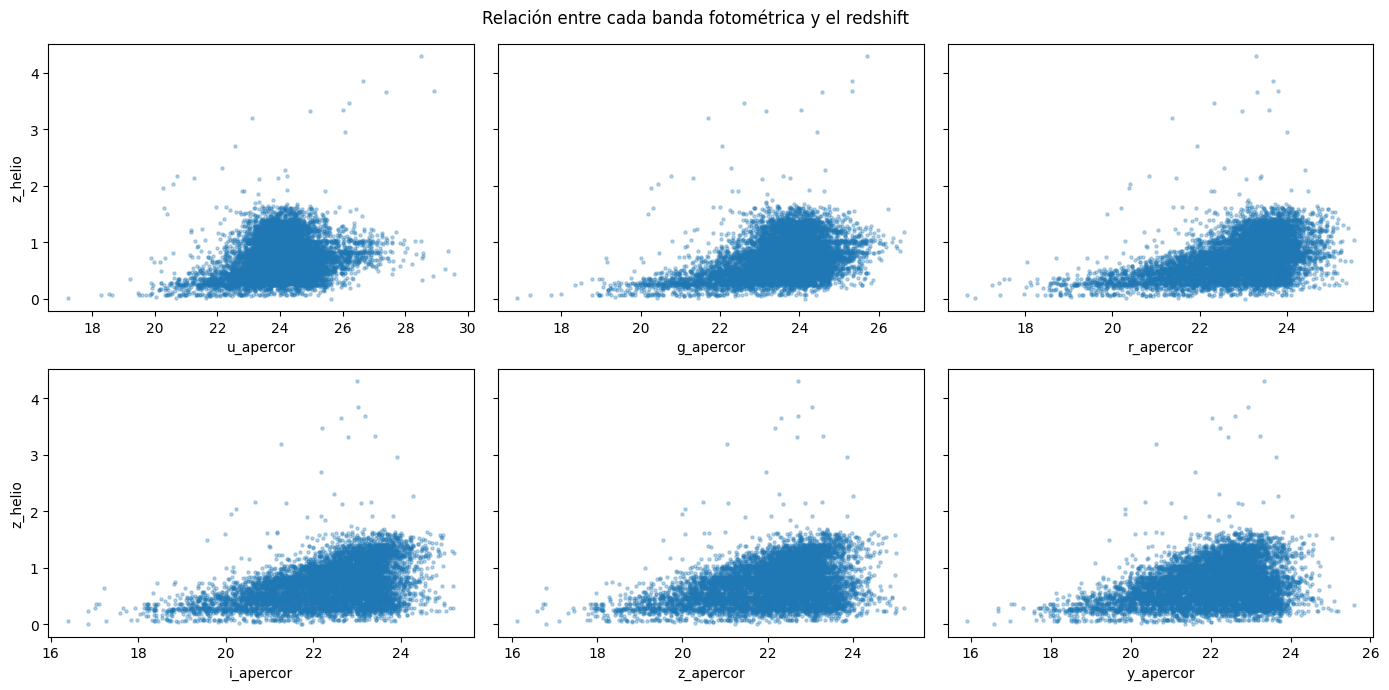

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, col in zip(axes.flat, cols):
    ax.scatter(X[col], y, s=5, alpha=0.3)
    ax.set_xlabel(col)
axes[0, 0].set_ylabel('z_helio')
axes[1, 0].set_ylabel('z_helio')
plt.suptitle('Relación entre cada banda fotométrica y el redshift')
plt.tight_layout()
plt.show()

**Pregunta previa:** mirando estos 6 gráficos, ¿Alguna banda individual parece más informativa que otras para predecir el redshift?  Explique

R: todas(menos u_apercor) tienen una tendencia en un incremento hasta 24. u_apercor en cambio tiene una forma gaussiana centrada en 24. A priori no se puede afirmar que alguna entrega más información sobre el redshift que otra, pero u_apercor es la única que se diferencia en relación de magnitud-redshift.

## Parte 1: Bootstrap a mano

Antes de correr el código: si toma una muestra bootstrap (con reemplazo) del mismo tamaño que tu dataset original, ¿qué fracción de las galaxias originales espera que **no** aparezca ni una sola vez en esa muestra?

R: se espera que no aparezca aproximadamente un 30%

In [ ]:
n = len(X)
idx = np.random.choice(n, n, replace=True)

fraccion_unica = len(np.unique(idx)) / n
print(f"Fracción de galaxias únicas en la muestra bootstrap: {fraccion_unica:.3f}")
print(f"Fracción OOB (fuera de esta muestra): {1 - fraccion_unica:.3f}")

Fracción de galaxias únicas en la muestra bootstrap: 0.629
Fracción OOB (fuera de esta muestra): 0.371


**Preguntas de reflexión:**

1. ¿El valor de "fracción OOB" que obtuvo se parece al ~37% que vimos en clase? ¿A qué límite matemático converge cuando $N \to \infty$?

R:Si se parece. Converge a 1/e

2. Si usara `replace=False` en vez de `True`, ¿qué pasaría con esta fracción? ¿Por qué bagging necesita específicamente muestreo *con* reemplazo?

R: La fracción de galaxias de la muestra sería 1, mientras que la fracción OOB bajaría a 0.0. Por lo que ésta relación nos indicaría que se está utilizando el total de a muestra de bootstrap.

### Bootstrap con Random Forest

El bootstrap que acabamos de hacer "a mano" es exactamente lo que `RandomForestRegressor` hace internamente para **cada uno** de sus árboles, de forma automática. Puedes verlo en sus parámetros:

```python
rf_ejemplo = RandomForestRegressor(n_estimators=200)
print(rf_ejemplo.get_params()['bootstrap'])  # True por defecto
```

Cuando entrenamos un Random Forest con `n_estimators=200`, internamente arma 200 muestras bootstrap distintas (una por árbol) exactamente como hicimos arriba, entrena un árbol en cada una, y guarda cuáles observaciones quedaron "fuera de la bolsa" (OOB) para cada árbol

In [ ]:
rf_ejemplo = RandomForestRegressor(n_estimators=200)
print(rf_ejemplo.get_params()['bootstrap'])  # True por defecto


True


## Parte 2: Un árbol de decisión vs. Random Forest

Antes de correr el código: vamos a entrenar un árbol de decisión sin restricción de profundidad, y un Random Forest de 200 árboles, cada uno 20 veces con distintas particiones train/test. ¿Cuál de los dos espera que tenga predicciones más *variables* de una partición a otra?

R: Se espera que el arbol de decisiones tenga predicciones más variables, ya que no tiene restricciones, mientras que el random forest está restringido a 200.

#### ShuffleSplit
Para ver qué tan *variable* es el desempeño de un modelo, necesitamos repetir el experimento de entrenar/evaluar muchas veces con particiones distintas, y mirar cuánto cambia el resultado de una repetición a otra.

`ShuffleSplit(n_splits=20, test_size=0.3)` genera 20 particiones aleatorias independientes (70% train / 30% test cada una), y `cross_val_score` se encarga de entrenar y evaluar el modelo en cada una automáticamente.

En el boxplot podemos ver qué tan dispersos son los resultados de cada modelo.



In [ ]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=20, test_size=0.3, random_state=0)

scores_arbol = cross_val_score(
    DecisionTreeRegressor(random_state=0), X, y,
    cv=cv, scoring='neg_mean_squared_error'
)
scores_rf = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=0), X, y,
    cv=cv, scoring='neg_mean_squared_error'
)

mse_arbol = -scores_arbol
mse_rf = -scores_rf

print(f"Árbol único, MSE promedio: {mse_arbol.mean():.4f}, desviación estándar: {mse_arbol.std():.4f}")
print(f"Random Forest, MSE promedio: {mse_rf.mean():.4f}, desviación estándar: {mse_rf.std():.4f}")

Árbol único, MSE promedio: 0.0545, desviación estándar: 0.0074
Random Forest, MSE promedio: 0.0283, desviación estándar: 0.0042


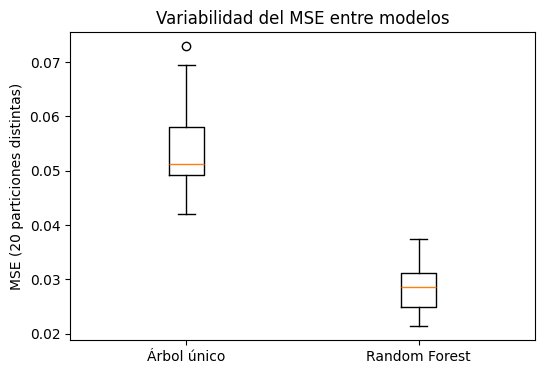

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot([mse_arbol, mse_rf], tick_labels=['Árbol único', 'Random Forest'])
plt.ylabel('MSE (20 particiones distintas)')
plt.title('Variabilidad del MSE entre modelos')
plt.show()

**Preguntas de reflexión:**

1. ¿Cuál modelo tiene mayor variabilidad (desviación estándar) del MSE entre las 20 particiones distintas? ¿Coincide con su predicción inicial?

R: el Árbol único tiene mayor desviación estandar.

2. Según la fórmula $\text{Var}_{\rm ensemble}(x) = \rho(x)\sigma^2(x) + \frac{1-\rho(x)}{M}\sigma^2(x)$ que vimos en clase, ¿qué término está bajando acá al promediar 200 árboles?

R: Al aumentar el numero de árboles se reduce la varianza del conjunto.

3. ¿Esperaría que el *bias* del Random Forest sea muy distinto al del árbol único? ¿Por qué sí o por qué no?

R: El bias del random forest debería ser menor al del árbol único, ya que tiene un sesgo menor debido a la segmetación del modelo

## Parte 3: OOB error vs. Cross-Validation

Antes de correr el código: OOB usa las galaxias que quedaron fuera de cada bootstrap para validar, sin necesitar un split explícito. ¿Espera que el error OOB sea parecido al de una validación cruzada de 5 folds, o sistemáticamente distinto?

R: Se espera que sean similares

In [ ]:
rf = RandomForestRegressor(n_estimators=200, oob_score=True, random_state=0)
rf.fit(X, y)
print(f"OOB R²: {rf.oob_score_:.3f}")

cv_scores = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=0), X, y, cv=5)
print(f"Cross-validation R² (5-fold): {np.mean(cv_scores):.3f}")

OOB R²: 0.769
Cross-validation R² (5-fold): 0.765


**Preguntas de reflexión:**

1. ¿Los dos valores de $R^2$ son parecidos? ¿Esperabas que lo fueran?

R: Son parecidos, varían por un orden de magnitud de 1e-3. Sí.

2. ¿Qué ventaja práctica tiene OOB frente a hacer 5-fold CV, en términos de tiempo de cómputo, considerando que aquí trabajamos con miles de galaxias?

R: El OOB requiere menos tiempo de computo, y permite ir probando el modelo mientras se entrena.

3. ¿En qué situación NO confiaría en el error OOB como estimador confiable del error de test? (pista: piensa en si las galaxias del catálogo son verdaderamente independientes entre sí, o si podría haber estructura espacial/de agrupamiento, por ejemplo galaxias del mismo cúmulo).

R: En un contexto donde el tamaño de la muestra sea pequeño, ya que puede inducir a sobreestimar el error.

## Parte 4: Feature Importance

Antes de correr el código: mirando el gráfico de la Parte 0 (bandas vs. redshift), ¿qué banda(s) espera que resulten más importantes?

R: el r_apercor, ya que a priori se ve una concentración mayor. centrada en 24, pero sin pasar valores mayores de éste.

r_apercor    0.369078
u_apercor    0.188421
i_apercor    0.133171
y_apercor    0.120177
z_apercor    0.098871
g_apercor    0.090282
dtype: float64


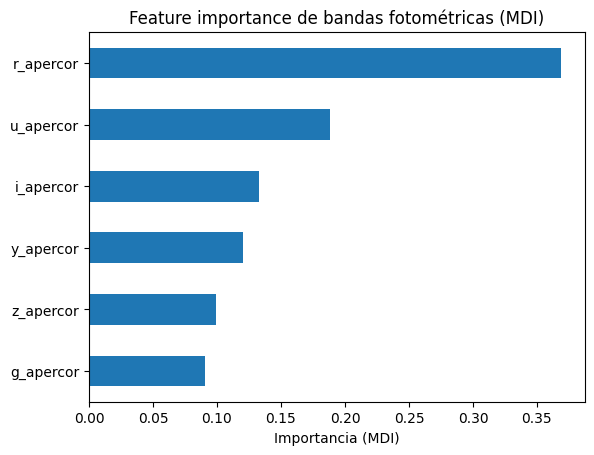

In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importancias)

importancias.plot(kind='barh')
plt.xlabel('Importancia (MDI)')
plt.title('Feature importance de bandas fotométricas (MDI)')
plt.gca().invert_yaxis()
plt.show()

### ¿MDI es confiable, o está sesgado hacia bandas más ruidosas?

Si observa el scatter plot de la Parte 0, notará que `u_apercor` tiene el rango de magnitudes más amplio y la nube de puntos más dispersa de las 6 bandas. El **Mean Decrease Impurity (MDI)** es conocido en la literatura (Strobl et al. 2007) por estar sesgado a favor de variables con mayor rango/variabilidad, simplemente porque le dan al árbol más posibles puntos de split, no necesariamente porque sean más informativas.

**Hipótesis a verificar:** ¿la posición alta de `u_apercor` en el ranking de MDI es un artefacto de este sesgo, o es una importancia genuina?

Para responder esto hay que comparar contra un criterio distinto, menos sensible a esta fuente de sesgo: la **permutation importance**, que mide directamente cuánto empeora el modelo si desordena aleatoriamente una columna.

r_apercor    1.687512
u_apercor    0.834474
i_apercor    0.518406
y_apercor    0.452200
g_apercor    0.373816
z_apercor    0.275869
dtype: float64


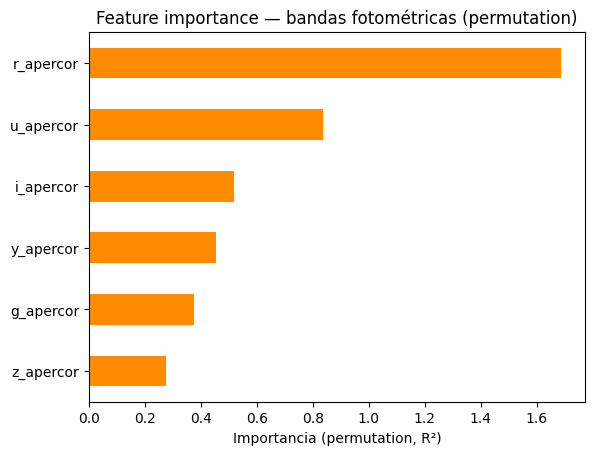

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X, y, n_repeats=10, random_state=0, scoring='r2')

importancias_perm = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print(importancias_perm)

importancias_perm.plot(kind='barh', color='darkorange')
plt.xlabel('Importancia (permutation, R²)')
plt.title('Feature importance — bandas fotométricas (permutation)')
plt.gca().invert_yaxis()
plt.show()

**Preguntas de reflexión:**

1. Compare el orden de las 6 bandas entre MDI y permutation importance. ¿`u_apercor` se mantiene en una posición alta en ambos criterios, o cae notoriamente en permutation? ¿Qué le dice eso sobre la hipótesis del sesgo de MDI en este caso particular?

R: Si se mantiene, y esto nos dice no tiene relación directa con el sesgo.

2. Si ambos criterios coinciden en el ranking, ¿qué explicación física alternativa se le ocurre para que una banda con mediciones más ruidosas siga siendo muy informativa? (pista: piense en el 4000A break y en qué banda cae esa discontinuidad espectral para distintos rangos de redshift).

R: aunque la banda u sea ruidosa, contiene información clave sobre la posicion del salto a 4000A, por lo que a medida que aumenta el redshift esta discontinuidad se desplaza entre otras bandas fotometricas.

3. Si repitiera este análisis con Gradient Boosting en vez de Random Forest, ¿esperaría el mismo ranking?

R: No necesariamente, porque el ranking probablemente sería similar para las variables más importantes, pero no idéntico, porque Gradient Boosting y Random Forest aprenden de forma distinta.

4. Si una banda tuviera importancia muy baja en ambos criterios, ¿la eliminaría del modelo sin más análisis, o qué verificaría primero?

R: No la eliminaría de inmediato. Primero verificaría si está correlacionada con otras bandas y evaluaría el rendimiento del modelo al eliminarla. Si el desempeño se mantiene, entonces sí podría descartarse.

## Parte 5:Esquema completo: optimización, predicción y métricas

Hasta ahora usamos un Random Forest con hiperparámetros por defecto. En esta parte armamos el flujo completo búsqueda de hiperparámetros con `GridSearchCV`, generación de predicciones para todo el dataset, y las métricas que reporta el paper que reproduce el notebook de clase.

**Antes de correr el código:** ¿espera que optimizar hiperparámetros mejore mucho el $R^2$ respecto al modelo por defecto, o solo un poco?

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict

parameters = {
    'max_depth': [3, 6, None],
    'max_features': [None, 4, 2],
    'n_estimators': [50, 100, 200],
    'min_samples_leaf': [1, 5, 10],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=5),
    parameters,
    cv=KFold(n_splits=5, shuffle=True, random_state=10),
    n_jobs=4,
    verbose=1,
)
grid.fit(X, y)

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor score (CV, R²): {grid.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejores hiperparámetros: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor score (CV, R²): 0.7698


### Predicciones con el mejor modelo

Usamos `cross_val_predict` para generar una predicción de $z$ para **cada** galaxia del dataset, pero siempre usando un modelo que no la vio durante su entrenamiento. Comparamos $z_{\rm true}$ vs. $z_{\rm pred}$

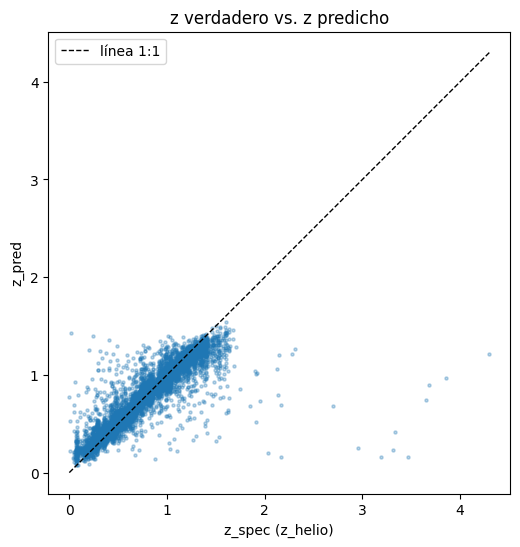

In [ ]:
best_model = grid.best_estimator_

y_pred = cross_val_predict(best_model, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=10))

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, s=5, alpha=0.3)
plt.plot([0, y.max()], [0, y.max()], 'k--', lw=1, label='línea 1:1')
plt.xlabel('z_spec (z_helio)')
plt.ylabel('z_pred')
plt.axis('square')
plt.legend()
plt.title('z verdadero vs. z predicho')
plt.show()

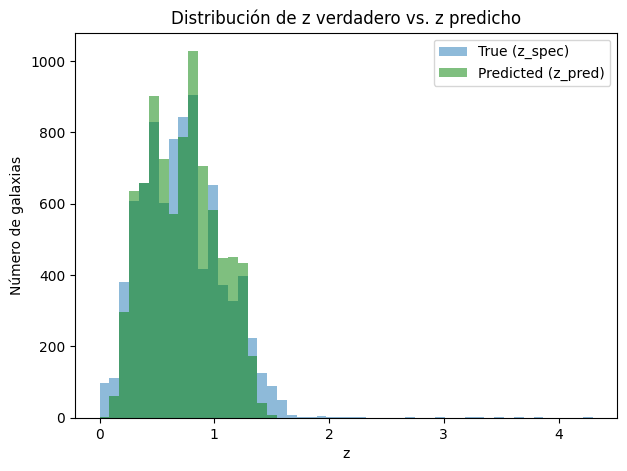

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(y, bins=50, density=False, alpha=0.5, range=(0, y.max()), label='True (z_spec)')
plt.hist(y_pred, bins=50, density=False, alpha=0.5, range=(0, y.max()), color='g', label='Predicted (z_pred)')
plt.xlabel('z')
plt.ylabel('Número de galaxias')
plt.legend()
plt.title('Distribución de z verdadero vs. z predicho')
plt.show()

### ¿Por qué la distribución predicha se ve más angosta que la real?

la distribución de `z_pred` (verde) tiende a ser más
angosta que la de `z_spec` (azul): pierde las colas altas y bajas de la
distribución real. Esto no es un error de tu modelo en particular; es una
característica estructural de **todos** los métodos basados en árboles.

**La razón:** un árbol de regresión predice, para cualquier observación nueva,
el **promedio del target de todos los puntos de entrenamiento que cayeron en la
misma hoja**. Si una galaxia tiene un redshift muy alto (raro en el catálogo),
sus "vecinas" en el espacio de features probablemente tienen redshifts más
moderados, así que la hoja que le toca termina prediciendo un promedio más bajo
que su valor real. Lo mismo ocurre en el otro extremo: una galaxia con z muy
bajo cae en una hoja junto a vecinas de z algo más alto, y su predicción queda
sobreestimada.

Este efecto se repite en todas las observaciones extremas del dataset, y el
resultado es que el histograma completo de predicciones se "encoge" hacia el
centro sistemáticamente subestimando los valores altos y sobreestimando los
bajos. Promediar muchos árboles (como hace Random Forest) no corrige este efecto;
de hecho, promediar promedios tiende a acentuarlo un poco más.


**Preguntas de reflexión:**

1. ¿El scatter se ve razonablemente cerca de la línea 1:1, o hay una desviación sistemática en algún rango de $z$?

R: si, se mantiene razonable, y sin una desviación sistempatica evidente. Solo se aprecia una dispersión algo mayor en los valores más altos de z, donde las predicciones son menos precisas.

2. ¿Se ve el efecto de estrechez en el scatter plot? ¿En qué extremo del rango de $z$ se nota más?

R: si, se aprecia el efecto de estrechez. El modelo tiende a sobreestimar los redshift bajis y subestimar los altos.

### Métricas MSE, $\sigma_{\rm NMAD}$ y fracción de outliers

Además del MSE, se reportan otras dos métricas

- **$\sigma_{\rm NMAD}$** (normalized median absolute deviation): una medida robusta de dispersión de los residuos, poco sensible a outliers. El residuo normalizado es

$$
\Delta z_i = \frac{z_{{\rm spec},i} - z_{{\rm pred},i}}{1 + z_{{\rm spec},i}}
$$

La dispersión robusta de los residuos es la normalized median absolute deviation:

$$
\sigma_{\rm NMAD} = 1.48 \times {\rm median}\left(
\left| \Delta z_i - {\rm median}(\Delta z) \right|
\right)
$$

- **$\eta$** (fracción de outliers): la proporción de galaxias cuyo residuo normalizado supera 0.15.
$$
\frac{|z_{\rm spec} - z_{\rm pred}|}{1 + z_{\rm spec}} > 0.15
$$

In [ ]:
mse = np.mean((y - y_pred)**2)

delta_z = (y - y_pred) / (1 + y)
sigma_nmad = 1.48 * np.median(np.abs(delta_z - np.median(delta_z)))
eta_outliers = np.mean(np.abs(delta_z) > 0.15)

print(f"MSE: {mse:.4f}")
print(f"sigma_NMAD: {sigma_nmad:.4f}")
print(f"Fracción de outliers (eta): {eta_outliers:.4f}")

MSE: 0.0292
sigma_NMAD: 0.0375
Fracción de outliers (eta): 0.0528


**Preguntas de reflexión:**

1. Compare tus valores de $\sigma_{\rm NMAD}$ y $\eta$ con los que obtiene el paper. ¿Está cerca, lejos, mejor o peor? ¿A qué le atribuye la diferencia, si la hay?

R: Mis valores son del mismo orden que los reportados en el paper, aunque presentan pequeñas diferencias. Estas pueden atribuirse a la partición aleatoria de entrenamiento/prueba, al ajuste de hiperparámetros y a diferencias en el preprocesamiento de los datos.

2. $\sigma_{\rm NMAD}$ usa la mediana en vez del promedio para medir dispersión. ¿Por qué esto la hace más robusta frente a outliers que, por ejemplo, la desviación estándar de $\Delta z$?

R: Porque la mediana es mucho menos sensible a valores extremos que el promedio. Así, unos pocos outliers no afectan significativamente el valor de $\sigma_{\rm NMAD}$, mientras que la desviación estándar puede aumentar considerablemente debido a esos errores grandes.

3. Si su $\eta$ (fracción de outliers) es alto, ¿qué haría primero: cambiar de modelo, agregar más features, o revisar la calidad de los datos de entrada? Justifique su prioridad.

R: Primero revisaría la calidad de los datos de entrada, porque un alto η puede deberse a mediciones ruidosas, valores erróneos o datos faltantes. Mejorar la calidad de los datos suele tener un mayor impacto que cambiar de modelo o agregar nuevas features.


## Cierre: Tarea 2

Acá usamos un subset de juguete. En la **Tarea 2** va a tener que decidir usted mismo/a los filtros de calidad, qué hacer con datos faltantes o anómalos, y posiblemente construir nuevas features.

La pregunta será **"¿qué decisiones debo tomar yo antes de que el método pueda funcionar bien?"**